In [1]:
# Load necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# We have 5 medications: drug A, drug B, drug C, drug X and drug Y. We want to predict which drug may be appropriate for future patients
# based off of Age, Sex, Blood Pressure, Sodium to Potassium and Cholesterol of patients.

In [2]:
# Load data 
df = pd.read_csv("drug200.csv")

In [3]:
# View first few rows of data
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [ ]:
# Check structure of data
df.info()

# 200 observations with 6 variables (5 predictors and 1 target (Drug))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [ ]:
# Check for missing values 
df.isnull().sum()

# Their are no missing values in data

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [ ]:
# Check for any duplicates
print(df.duplicated().sum())    # Data does not have any duplicates

0


In [13]:
# Check unique values for Sex, Cholesterol and Drug
cols = ["Sex", "Cholesterol", "Drug"]

for col in cols:
    print(f"Unique values for {col}")
    print(df[col].unique())
    print()

Unique values for Sex
['F' 'M']

Unique values for Cholesterol
['HIGH' 'NORMAL']

Unique values for Drug
['drugY' 'drugC' 'drugX' 'drugA' 'drugB']



In [17]:
# View summary statistics for all variables
df.describe(include=['object', 'int64', 'float64'])

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
count,200.000000,200,200,200,200.000000,200
unique,NaN,2,3,2,NaN,5
top,NaN,M,HIGH,HIGH,NaN,drugY
freq,NaN,104,77,103,NaN,91
mean,44.315000,NaN,NaN,NaN,16.084485,NaN
std,16.544315,NaN,NaN,NaN,7.223956,NaN
min,15.000000,NaN,NaN,NaN,6.269000,NaN
25%,31.000000,NaN,NaN,NaN,10.445500,NaN
50%,45.000000,NaN,NaN,NaN,13.936500,NaN
75%,58.000000,NaN,NaN,NaN,19.380000,NaN


In [19]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

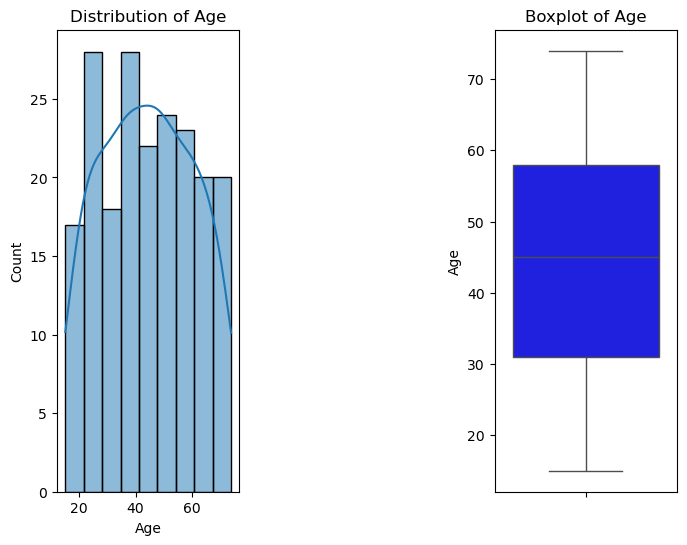

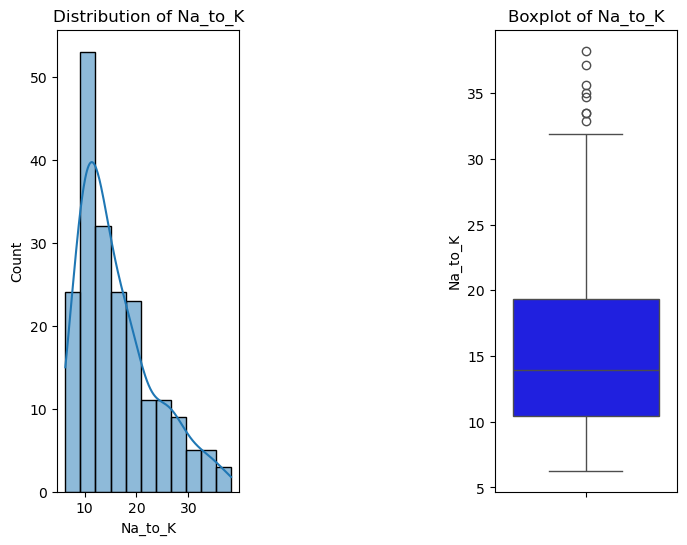

In [ ]:
# Look at distribution of Numerical variables and Boxplots

for col in num_cols:
    plt.figure(figsize=(8,6))
    
    # Histograms
    plt.subplot(1,3,1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)

    # Boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[col], color='blue')
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

    plt.show()

# Sodium to Potassium is postively skewed 
# There are no outliers present 

In [23]:
cat_cols = df.select_dtypes(include=['object']).columns

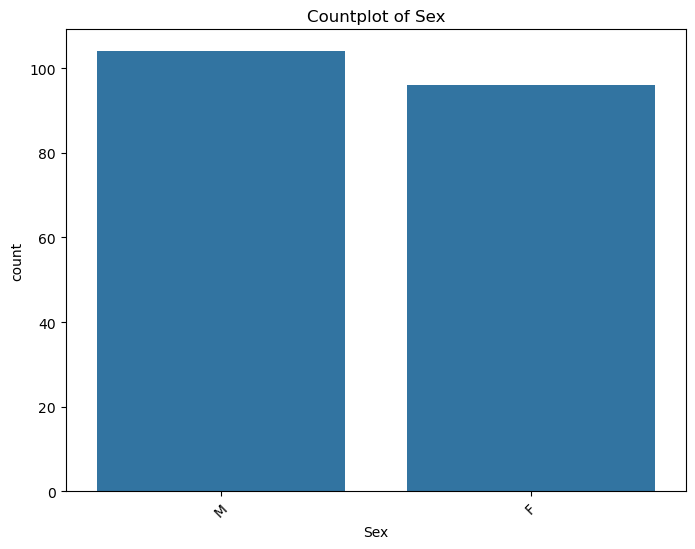

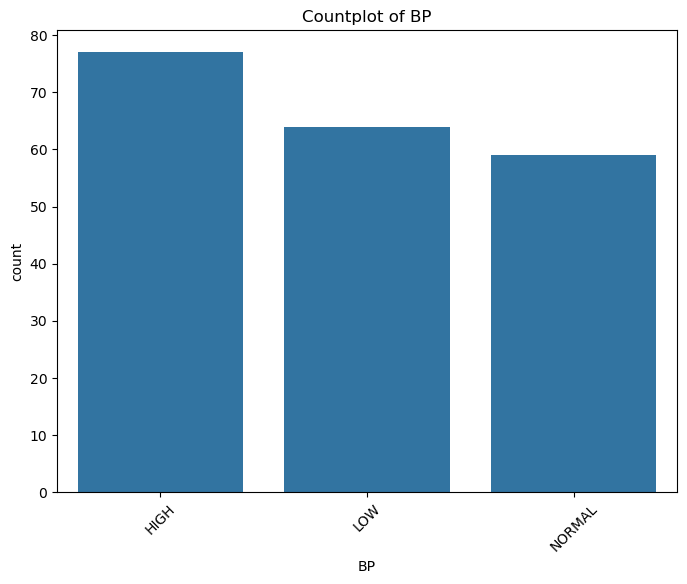

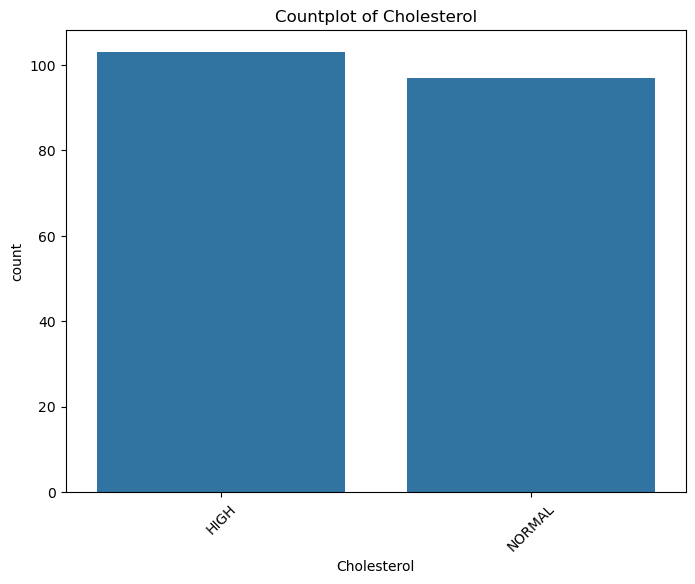

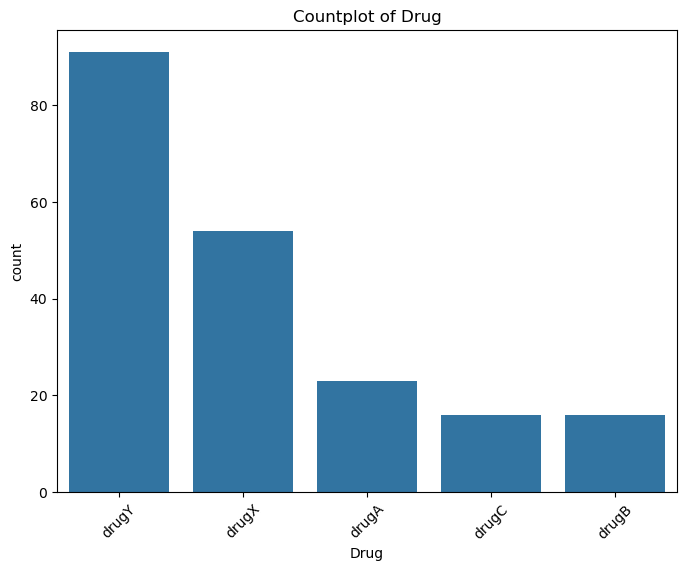

In [24]:
# Let's view Count plots for character variables
for col in cat_cols:
    plt.figure(figsize=(8,6))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [28]:
# Let's prepare to perform Decision Tree Classification
# Need to convert character variables/columns to numerical to use for Decision Trees

from sklearn.preprocessing import LabelEncoder

char_cols = ["Sex", "BP", "Cholesterol", "Drug"]

# Create dictionary that stores encoders
encoders = {}

# Fit and transform each column
for col in char_cols:
    enc = LabelEncoder()
    df[col] = enc.fit_transform(df[col])
    encoders[col] = enc


In [29]:
# View dataframe to see if encoding worked
df.head()


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,4
1,47,1,1,0,13.093,2
2,47,1,1,0,10.114,2
3,28,0,2,0,7.798,3
4,61,0,1,0,18.043,4


In [32]:
# drugA = 0, drugB = 1, drugC = 2, drugX = 3, drugY = 4

In [33]:
# Set random seed for reproducibility
np.random.seed(42)

# Select features and target variable
X = df.drop('Drug', axis=1)
y = df["Drug"]

In [ ]:
# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [37]:
# Check shape of training and testing sets
print(f"X Train Size: {X_train.shape}")
print(f"X Test Size: {X_test.shape}")
print(f"Y Train Size: {y_train.shape}")
print(f"Y Test Size: {y_test.shape}")

X Train Size: (140, 5)
X Test Size: (60, 5)
Y Train Size: (140,)
Y Test Size: (60,)


In [38]:
# Fit decision Tree
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [39]:
# Make predictions
y_pred = model.predict(X_test)

In [ ]:
# Evaluate model
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"\nClassification Report:\n", classification_report(y_test, y_pred))

# Model a 98% Accuracy meaning that the model can correctly predict the best drug for a future patient 98% of the time.


Accuracy: 0.98

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.80      0.89         5
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        27

    accuracy                           0.98        60
   macro avg       0.97      0.96      0.96        60
weighted avg       0.99      0.98      0.98        60



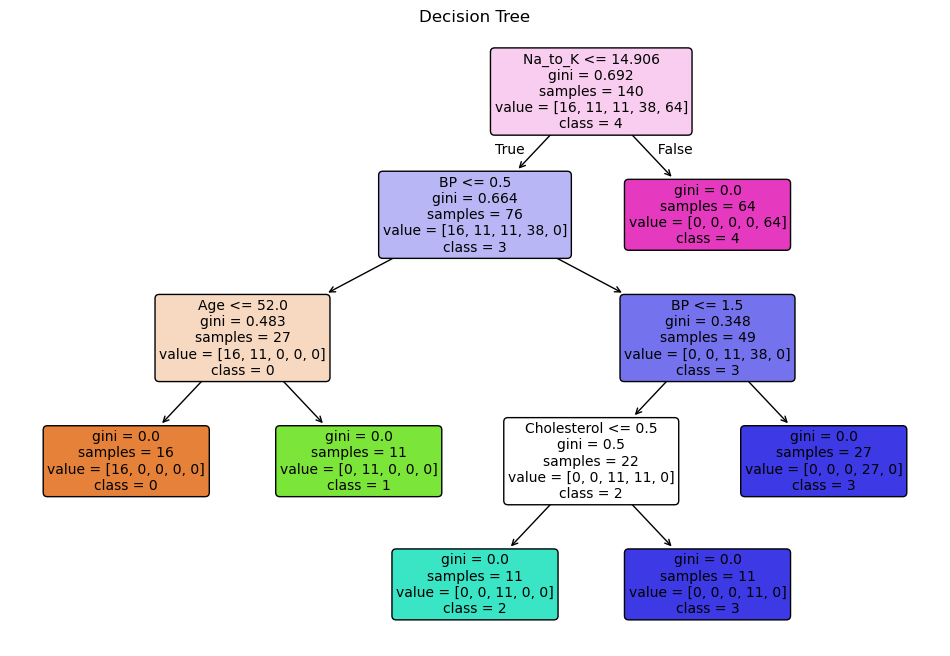

In [43]:
# Visualize Tree
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=X.columns,
          class_names=[str(c) for c in np.unique(y)],
          filled=True, rounded=True, fontsize=10)
plt.title(f"Decision Tree")
plt.show()

In [ ]:
# Let's look at the importance of each feature
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n", feat_importance)

# Sodium to Potassium is the most important feature in classifying correct drug, followed by BP (Blood Pressure)
# Sex does not have any importance in the model and can actually be removed from the model. 


Feature Importance:
        Feature  Importance
4      Na_to_K    0.479234
2           BP    0.272633
0          Age    0.134581
3  Cholesterol    0.113553
1          Sex    0.000000
